/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature nam

Animation saved as pca_biplot_animation.gif


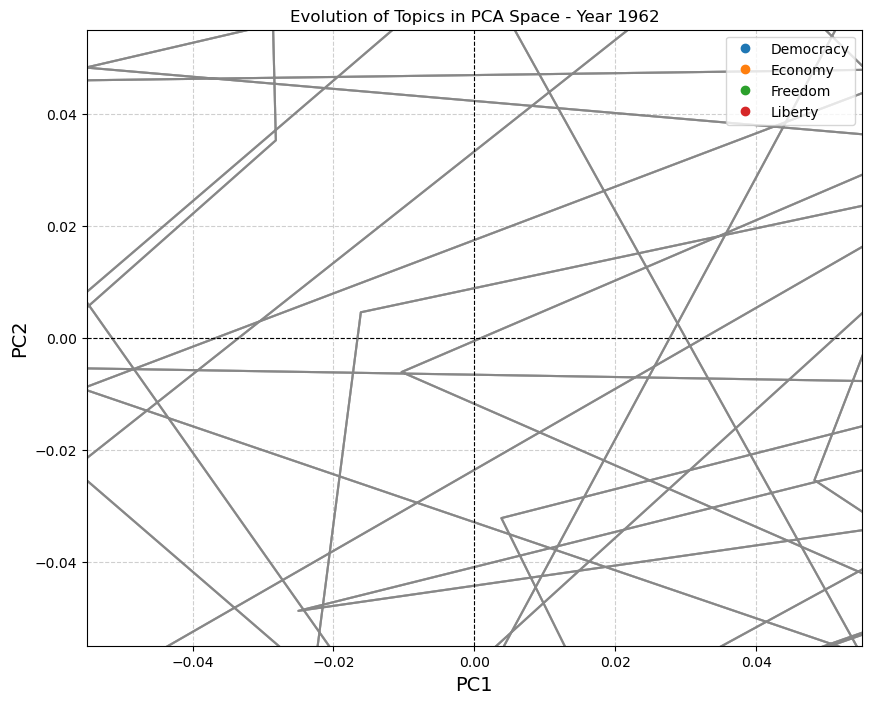

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load dataset
file_path = "/Users/kylejonespatricia/Documents/Combined_sentiment 1840-1963.csv"  # Update with your file path
df = pd.read_csv(file_path)


# Pivot data: rows = years, columns = topics, values = composite sentiment scores
df_pivot = df.pivot(index="year", columns="Topic", values="composite").dropna()

# Perform PCA across topics
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_pivot)  # Now each row (year) is represented by PC1, PC2

# Convert PCA results to DataFrame
df_pca = pd.DataFrame(pca_result, index=df_pivot.index, columns=["PC1", "PC2"])

# Store PCA values for each topic over time
topic_positions = {topic: [] for topic in df_pivot.columns}

for year in df_pivot.index:
    topic_scores = df_pivot.loc[year].values.reshape(1, -1)  # Reshape to 2D
    topic_pca = pca.transform(topic_scores)  # Project topics into PC1-PC2 space
    for i, topic in enumerate(df_pivot.columns):
        topic_positions[topic].append(topic_pca[0])  # Store topic position

# Convert to NumPy arrays
for topic in topic_positions:
    topic_positions[topic] = np.array(topic_positions[topic])

# Set up the animation figure
fig, ax = plt.subplots(figsize=(10, 8))

# Initialize scatter points and trails
scatters = {topic: ax.plot([], [], marker="o", linestyle="", label=topic)[0] for topic in df_pivot.columns}
trails = {topic: ax.plot([], [], linestyle="-", color="gray", alpha=0.5)[0] for topic in df_pivot.columns}

# Set plot formatting
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
ax.set_title("Evolution of Topics in PCA Space Over Time", fontsize=16)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)

# Update function for animation
def update(frame):
    year = df_pivot.index[frame]
    ax.set_title(f"Evolution of Topics in PCA Space - Year {year}")

    for topic in df_pivot.columns:
        x_positions = topic_positions[topic][:frame+1, 0]
        y_positions = topic_positions[topic][:frame+1, 1]

        scatters[topic].set_data([x_positions[-1]], [y_positions[-1]])  # Current position
        trails[topic].set_data(x_positions, y_positions)  # Historical trail

    return list(scatters.values()) + list(trails.values())

# Create animation
ani = animation.FuncAnimation(fig, update, frames=len(df_pivot.index), interval=200, blit=True)

# Save as GIF using Pillow
gif_path = "pca_biplot_animation.gif"
ani.save(gif_path, writer="pillow", fps=10)

print(f"Animation saved as {gif_path}")


Animation saved as democracy_sentiment_animation.gif


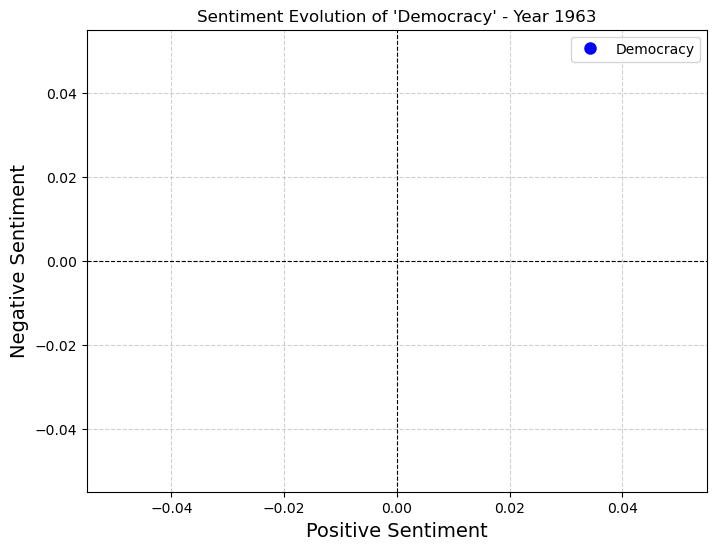

In [11]:

# Filter only for Democracy
df_democracy = df[df["Topic"] == "Democracy"]

# Ensure data is sorted by year
df_democracy = df_democracy.sort_values("year")

# Extract X and Y values
years = df_democracy["year"].values
x_values = df_democracy["positive"].values  # X-axis: Positive Sentiment
y_values = df_democracy["negative"].values  # Y-axis: Negative Sentiment

# Set up the animation figure
fig, ax = plt.subplots(figsize=(8, 6))

# Initialize scatter plot and trail line
scatter, = ax.plot([], [], "bo", markersize=8, label="Democracy")
trail, = ax.plot([], [], "gray", linestyle="-", alpha=0.5)

# Set plot formatting
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Positive Sentiment", fontsize=14)
ax.set_ylabel("Negative Sentiment", fontsize=14)
ax.set_title("Sentiment Evolution of 'Democracy' Over Time", fontsize=16)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)

# Update function for animation
def update(frame):
    year = years[frame]
    ax.set_title(f"Sentiment Evolution of 'Democracy' - Year {year}")

    # Update point position
    scatter.set_data([x_values[frame]], [y_values[frame]])

    # Update trail
    trail.set_data(x_values[:frame+1], y_values[:frame+1])

    return scatter, trail

# Create animation
ani = animation.FuncAnimation(fig, update, frames=len(years), interval=300, blit=True)

# Save as GIF using Pillow
gif_path = "democracy_sentiment_animation.gif"
ani.save(gif_path, writer="pillow", fps=10)

print(f"Animation saved as {gif_path}")


In [ ]:
# Reload necessary libraries after execution state reset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Load the dataset
file_path = "/mnt/data/Combined_sentiment 1850-1963.csv"
df = pd.read_csv(file_path)

# Filter only for Democracy
df_democracy = df[df["Topic"] == "Democracy"]

# Ensure data is sorted by year
df_democracy = df_democracy.sort_values("year")

# Extract X and Y values
years = df_democracy["year"].values
x_values = df_democracy["positive"].values  # X-axis: Positive Sentiment
y_values = df_democracy["negative"].values  # Y-axis: Negative Sentiment

# Check the range of values
x_min, x_max = x_values.min(), x_values.max()
y_min, y_max = y_values.min(), y_values.max()

(x_min, x_max, y_min, y_max)


/var/folders/c8/g7bx7g1552g19xn4q4dd583r0000gn/T/ipykernel_33491/1389240982.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_sentiment = df.groupby(["Topic", "period"])["composite"].mean().unstack()


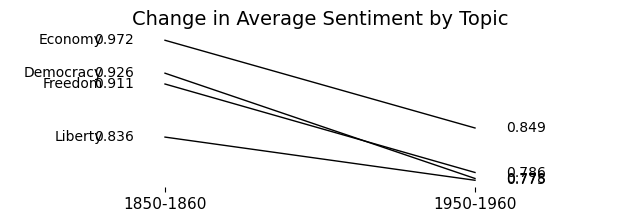

In [18]:
import pandas as pd
import matplotlib.pyplot as plt


# Define time periods
df["period"] = pd.cut(df["year"], bins=[1850, 1860, 1960], labels=["1850-1860", "1950-1960"], include_lowest=True)

# Compute mean sentiment per topic in each period
avg_sentiment = df.groupby(["Topic", "period"])["composite"].mean().unstack()

# Drop topics with missing values in either period
avg_sentiment = avg_sentiment.dropna()

# Create the slope plot
fig, ax = plt.subplots(figsize=(8, len(avg_sentiment) * 0.5))

for topic, (early, late) in avg_sentiment.iterrows():
    ax.plot([0, 1], [early, late], color="black", linewidth=1)
    ax.text(-0.1, early, f"{early:.3f}", va="center", ha="right", fontsize=10)
    ax.text(1.1, late, f"{late:.3f}", va="center", ha="left", fontsize=10)
    ax.text(-0.2, early, topic, va="center", ha="right", fontsize=10)

# Formatting
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(["1850-1860", "1950-1960"], fontsize=11)
ax.set_yticks([])
ax.set_title("Change in Average Sentiment by Topic", fontsize=14)

# Hide spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.savefig("sentiment_slope_plot.png", dpi=300, bbox_inches="tight")
plt.show()


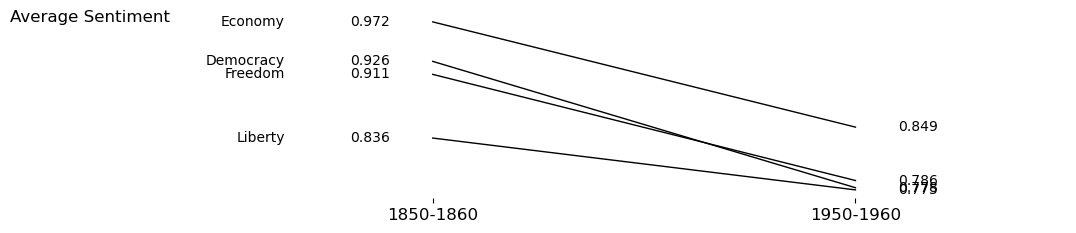

In [23]:

# Define time periods
df["period"] = pd.cut(df["year"], bins=[1850, 1860, 1960], labels=["1850-1860", "1950-1960"], include_lowest=True)

# Compute mean sentiment per topic in each period
avg_sentiment = df.groupby(["Topic", "period"], observed=True)["composite"].mean().unstack()

# Drop topics with missing values in either period
avg_sentiment = avg_sentiment.dropna()

# Create the slope plot with more spacing
fig, ax = plt.subplots(figsize=(12, len(avg_sentiment) * 0.6))

# Plot slope lines
for topic, (early, late) in avg_sentiment.iterrows():
    ax.plot([0, 1], [early, late], color="black", linewidth=1)
    ax.text(-0.1, early, f"{early:.3f}", va="center", ha="right", fontsize=10)
    ax.text(1.1, late, f"{late:.3f}", va="center", ha="left", fontsize=10)
    ax.text(-0.35, early, topic, va="center", ha="right", fontsize=10)

# Formatting
ax.set_xlim(-0.7, 1.5)  # Extra space on the left for title
ax.set_xticks([0, 1])
ax.set_xticklabels(["1850-1860", "1950-1960"], fontsize=12)
ax.set_yticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Title positioned on the side
ax.text(-1.0, avg_sentiment.max().max(), "Average Sentiment", fontsize=12, ha="left")

plt.savefig("sentiment_slope_plot.png", dpi=300, bbox_inches="tight")
plt.show()
